In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [46]:
#Subspace 
L = 2*np.pi
B = 2*np.pi

#Constants
nu = 0.01
T = 3
dt = 0.2

#Particles
Nxp = 100
Nyp = 100

h = L/Nxp

#Particles in grid
X,Y = np.meshgrid(np.linspace(0,L,Nxp,endpoint=False),
                  np.linspace(0,B,Nyp,endpoint=False),indexing="ij")

#Finding vorticity of particles analytically
W = vorticity(X,Y, 0, nu)

#Storing information in particle
particles = []
for x, y, w in zip(X.ravel(), Y.ravel(), W.ravel()):
    p = {}
    p['pos'] = x + y * 1j
    #p['y'] = y
    p['a'] = w * (h ** 2)
    particles.append(p)

# Mesh
Nxm = Nxp
Nym = Nyp

mesh = np.zeros((Nxm, Nym))

for t in np.arange(0, T, dt):

    wm = p2m(particles, mesh, h)

    um, wm = grid_solver(wm, h)

    m2p(particles, wm, um, h)

    advect(particles, dt, L, B)       


wm = p2m(particles, mesh, h)

In [47]:
x = np.linspace(0, L, Nxm, endpoint=False)
y = np.linspace(0, B, Nym, endpoint=False)

X, Y = np.meshgrid(x, y, indexing="ij")

w_exact = vorticity(X, Y, T, nu)

error = wm - w_exact

L2 = np.sqrt(np.mean(error**2))

L2_rel = np.linalg.norm(error) / np.linalg.norm(w_exact)

Linf = np.max(np.abs(error))

print(L2, L2_rel, Linf)

0.2518220224256679 0.2673938266365393 0.9019615222260755


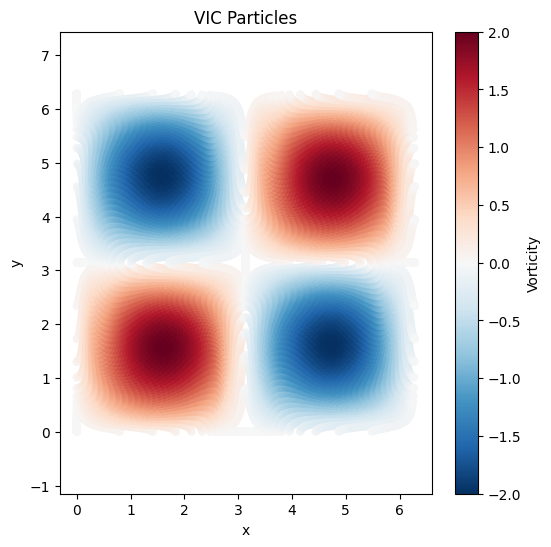

In [39]:
def plot_vic_particles(particles, h, title="VIC Particles"):

    x = np.array([p["pos"].real for p in particles])
    y = np.array([p["pos"].imag for p in particles])

    # Convert circulation back to vorticity
    w = np.array([p["a"] for p in particles]) / h**2

    vmax = np.max(np.abs(w))

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        y,
        c=w,
        cmap="RdBu_r",
        s=25,
        vmin=-vmax,
        vmax=vmax
    )

    plt.colorbar(label="Vorticity")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.title(title)

    plt.show()

plot_vic_particles(particles, h)

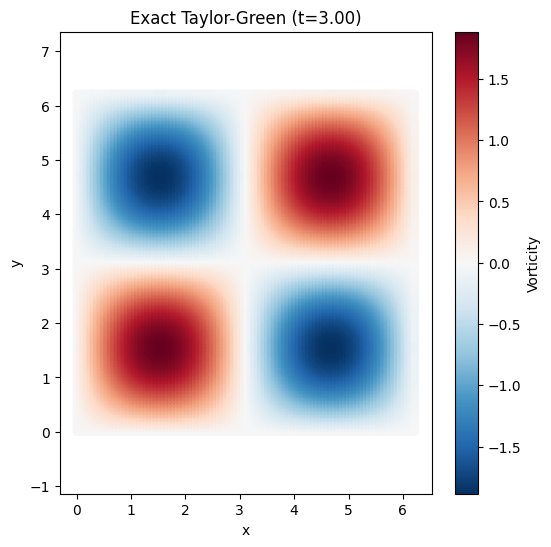

In [42]:
def plot_exact_taylor_green(L, B, Nx, Ny, t, nu):

    x = np.linspace(0, L, Nx, endpoint=False)
    y = np.linspace(0, B, Ny, endpoint=False)

    X, Y = np.meshgrid(x, y, indexing="ij")

    W = vorticity(X, Y, t, nu)

    vmax = np.max(np.abs(W))

    plt.figure(figsize=(6,6))

    plt.scatter(
        X.ravel(),
        Y.ravel(),
        c=W.ravel(),
        s=25,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax
    )

    plt.colorbar(label="Vorticity")
    plt.title(f"Exact Taylor-Green (t={t:.2f})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.show()

plot_exact_taylor_green(L, B, Nxp, Nyp, T, nu)

In [ ]:
def plot_exact_particles(particles, t, nu, title="Exact Taylor-Green"):

    x = np.array([p["pos"].real for p in particles])
    y = np.array([p["pos"].imag for p in particles])

    w = vorticity(x, y, t, nu)

    vmax = np.max(np.abs(w))

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        y,
        c=w,
        cmap="RdBu_r",
        s=25,
        vmin=-vmax,
        vmax=vmax
    )

    plt.colorbar(label="Vorticity")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.title(title)

    plt.show()

In [4]:
L = 2*np.pi
B = 2*np.pi

Nxp = 100
Nyp = 100

nu = 0.01
t = 0.0
dt = 0.1

x = np.linspace(0,L,Nxp,endpoint=False)
y = np.linspace(0,B,Nyp,endpoint=False)

X,Y = np.meshgrid(x,y,indexing="ij")



Nxm = 101
Nym = 101

mesh = np.empty((Nxm, Nym), dtype=object)

for i in range(Nxm):
    for j in range(Nym):
        mesh[i, j] = {'a' : 0}



h = L/Nxp

In [5]:
def vorticity(x,y,t,nu):
    decay = np.exp(-2*nu*t)
    return 2*np.sin(x)*np.sin(y)*decay

W = vorticity(X,Y, t, nu)

In [4]:
particles = []
for x, y, w in zip(X.ravel(), Y.ravel(), W.ravel()):
    p = {}
    p['pos'] = x + y * 1j
    #p['y'] = y
    p['a'] = w * (h ** 2)
    particles.append(p)

In [20]:
"""def p2m(particles, mesh, h):

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        i = int(xp // h)
        j = int(yp // h)

        dx = (xp - i*h)/h
        dy = (yp - j*h)/h

        mesh[i, j]         += (1-dx)*(1-dy) * p["a"] / h**2
        mesh[i+1, j]       += dx*(1-dy)     * p["a"] / h**2
        mesh[i, j+1]       += (1-dx)*dy     * p["a"] / h**2
        mesh[i+1, j+1]     += dx*dy         * p["a"] / h**2

    return mesh"""

def p2m(particles, mesh, h):

    Nx, Ny = mesh.shape

    mesh.fill(0.0)

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        i = int(xp // h)
        j = int(yp // h)

        dx = (xp - i*h)/h
        dy = (yp - j*h)/h

        ip = (i + 1) % Nx
        jp = (j + 1) % Ny

        mesh[i,  j ] += (1-dx)*(1-dy) * p["a"] / h**2
        mesh[ip, j ] += dx*(1-dy)     * p["a"] / h**2
        mesh[i,  jp] += (1-dx)*dy     * p["a"] / h**2
        mesh[ip, jp] += dx*dy         * p["a"] / h**2

    return mesh

In [6]:
#p2m([{'pos' : 0.3 + 0.7j, 'a' : 10}], mesh, 1)

p2m(particles, mesh, h)

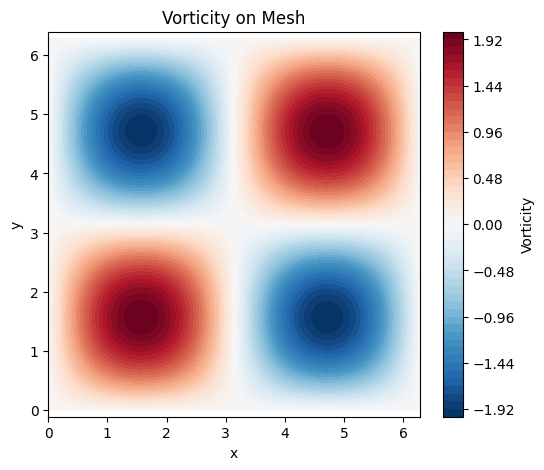

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Extract vorticity from mesh
omega = np.zeros((Nxm, Nym))

for i in range(Nxm):
    for j in range(Nym):
        omega[i, j] = mesh[i, j]["a"]

# Coordinates of the mesh
Lx = 2*np.pi
Ly = 2*np.pi

x = np.linspace(0, Lx, Nxm)
y = np.linspace(0, Ly, Nym)

X, Y = np.meshgrid(x, y, indexing="ij")

# Plot
plt.figure(figsize=(6,5))

plt.contourf(X, Y, omega, levels=50, cmap="RdBu_r")
plt.colorbar(label="Vorticity")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Vorticity on Mesh")
plt.axis("equal")

plt.show()

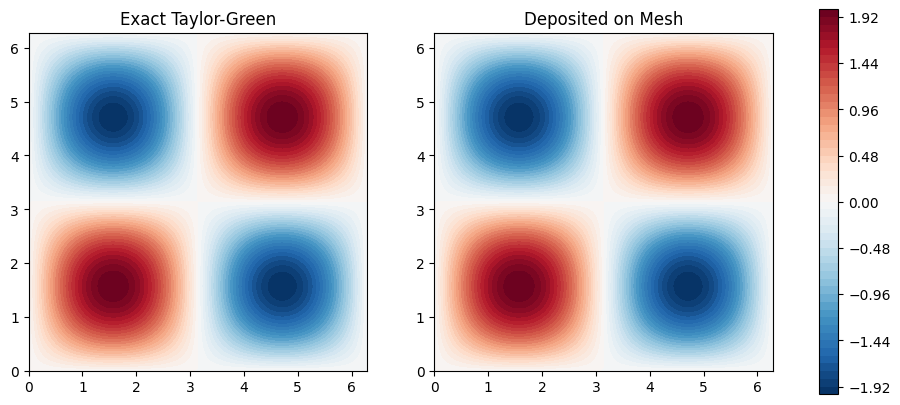

In [10]:
omega_exact = 2*np.sin(X)*np.sin(Y)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

c1 = ax[0].contourf(X, Y, omega_exact, levels=50, cmap="RdBu_r")
ax[0].set_title("Exact Taylor-Green")
ax[0].set_aspect("equal")

c2 = ax[1].contourf(X, Y, omega, levels=50, cmap="RdBu_r")
ax[1].set_title("Deposited on Mesh")
ax[1].set_aspect("equal")

plt.colorbar(c2, ax=ax)
plt.show()

In [7]:
def grid_solver (omega, h):

    Nx = omega.shape[0]
    Ny = omega.shape[1]

    dx, dy = h, h

    kx=2*np.pi*np.fft.fftfreq(Nx,d=dx)
    ky=2*np.pi*np.fft.fftfreq(Ny,d=dy)

    KX,KY=np.meshgrid(kx,ky,indexing="ij")
    K2=KX**2+KY**2

    K2[0,0]=1.0


    #diffusion

    omega_hat=np.fft.fft2(omega)

    diffusion = np.exp(-nu * K2 * dt)

    omega_hat *= diffusion

    omega = np.real(np.fft.ifft2(omega_hat))


    #poisson solver

    omega_hat=np.fft.fft2(omega)

    psi_hat=omega_hat/K2
    psi_hat[0,0]=0.0

    psi=np.real(np.fft.ifft2(psi_hat))

    u_hat=1j*KY*psi_hat
    v_hat=-1j*KX*psi_hat

    u=np.real(np.fft.ifft2(u_hat))
    v=np.real(np.fft.ifft2(v_hat))

    U = u + 1j * v   

    return U, W

In [16]:
u, w = grid_solver(omega, h)

In [17]:
"""def m2p(pos, U, h):

    xp = np.real(pos)
    yp = np.imag(pos)

    i = int(xp // h)
    j = int(yp // h)

    dx = (xp - i*h) / h
    dy = (yp - j*h) / h

    up = (
        U[i, j]     * (1-dx) * (1-dy) +
        U[i+1, j]   * dx     * (1-dy) +
        U[i, j+1]   * (1-dx) * dy +
        U[i+1, j+1] * dx     * dy
    )

    return up



def m2p(particles, w, U, h):

    for p in particles:

        xp = np.real(p['pos'])
        yp = np.imag(p['pos'])

        i = int(xp // h)
        j = int(yp // h)

        dx = (xp - i*h) / h
        dy = (yp - j*h) / h

        up = (
                U[i, j]     * (1-dx) * (1-dy) +
                U[i+1, j]   * dx     * (1-dy) +
                U[i, j+1]   * (1-dx) * dy +
                U[i+1, j+1] * dx     * dy
            )

        p['u'] = up

        wp = (
                w[i, j]     * (1-dx) * (1-dy) +
                w[i+1, j]   * dx     * (1-dy) +
                w[i, j+1]   * (1-dx) * dy +
                w[i+1, j+1] * dx     * dy
            )

        p['a'] = wp * (h ** 2)
"""


def m2p(particles, w, U, h):

    Nx, Ny = w.shape

    for p in particles:

        xp = np.real(p["pos"])
        yp = np.imag(p["pos"])

        # Base cell indices (periodic)
        i = int(xp // h) % Nx
        j = int(yp // h) % Ny

        # Fractional distance inside the cell
        dx = (xp - i*h) / h
        dy = (yp - j*h) / h

        # Neighbouring indices (periodic)
        ip = (i + 1) % Nx
        jp = (j + 1) % Ny

        # Interpolate velocity
        up = (
            U[i,  j ] * (1-dx) * (1-dy) +
            U[ip, j ] * dx     * (1-dy) +
            U[i,  jp] * (1-dx) * dy +
            U[ip, jp] * dx     * dy
        )

        p["u"] = up

        # Interpolate vorticity
        wp = (
            w[i,  j ] * (1-dx) * (1-dy) +
            w[ip, j ] * dx     * (1-dy) +
            w[i,  jp] * (1-dx) * dy +
            w[ip, jp] * dx     * dy
        )

        p["a"] = wp * h**2

In [22]:
m2p(particles, w, u, h)

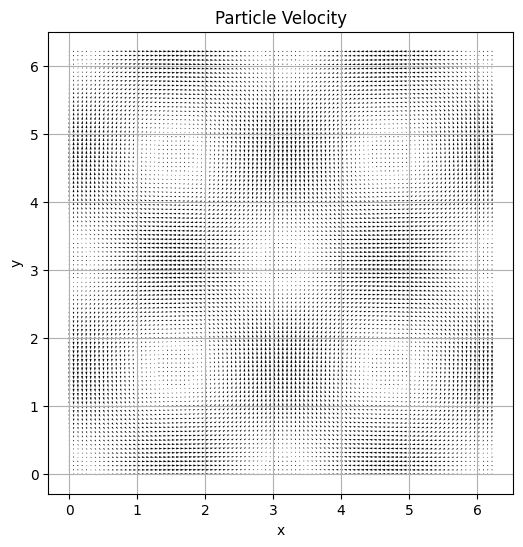

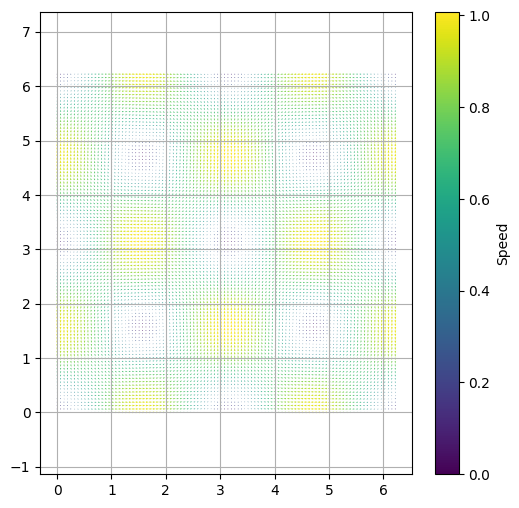

In [24]:
import matplotlib.pyplot as plt

# Extract positions
x = [p["pos"].real for p in particles]
y = [p["pos"].imag for p in particles]

# Extract velocities
u = [p["u"].real for p in particles]
v = [p["u"].imag for p in particles]

plt.figure(figsize=(6,6))
plt.quiver(x, y, u, v)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Particle Velocity")
plt.axis("equal")
plt.grid(True)
plt.show()


import numpy as np

speed = np.sqrt(np.array(u)**2 + np.array(v)**2)

plt.figure(figsize=(6,6))
plt.quiver(x, y, u, v, speed, cmap="viridis")

plt.colorbar(label="Speed")
plt.axis("equal")
plt.grid(True)
plt.show()

In [19]:
"""def advect_rk2(particles, U, h, dt):

    for p in particles:

        k1 = m2p(p["pos"], U, h)

        mid_pos = p["pos"] + 0.5 * dt * k1

        k2 = m2p(mid_pos, U, h)

        p["u"] = k2
        p["pos"] += dt * k2"""

"""def advect(particles, dt):
    for p in particles:
        p['pos'] += p['u'] * dt"""

def advect(particles, dt, Lx, Ly):

    for p in particles:

        p["pos"] += p["u"] * dt

        x = np.real(p["pos"]) % Lx
        y = np.imag(p["pos"]) % Ly

        p["pos"] = x + 1j*y